# 🩺 **Diabetes Prediction Using Ensemble Machine Learning**
### **Bagging • Boosting • Voting Classifiers**

---


##  **Project Overview**

This project aims to build a robust machine learning system that predicts whether a patient is diabetic based on medical features such as glucose level, BMI, blood pressure, age, and more.

To achieve high accuracy and reliability, we apply **three major ensemble learning families**:

- **Bagging Models** (reduce variance)
  - Random Forest
  - Bagging Classifier

- **Boosting Models** (reduce bias)
  - AdaBoost
  - Gradient Boosting
  - XGBoost

- **Voting Ensemble** (combine all models)
  - Hard Voting
  - Soft Voting

The project compares the performance of these models and explains the **mathematical intuition** behind each ensemble method.

---

## **Chapter 1 – Data Preprocessing**

### 1. Install & import libraries

In [3]:
!pip install -r requirements.txt

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### 2. Load dataset

In [15]:
df=pd.read_csv('diabetes_prediction_dataset.csv')

In [16]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


## **Chapter 2 – Exploratory Data Analysis (EDA)**

The purpose of Exploratory Data Analysis (EDA) is to understand the structure, distribution, and relationships of the features in the diabetes dataset. This helps us identify data quality issues, patterns, correlations, and the importance of each feature in predicting diabetes.


<Axes: xlabel='diabetes', ylabel='count'>

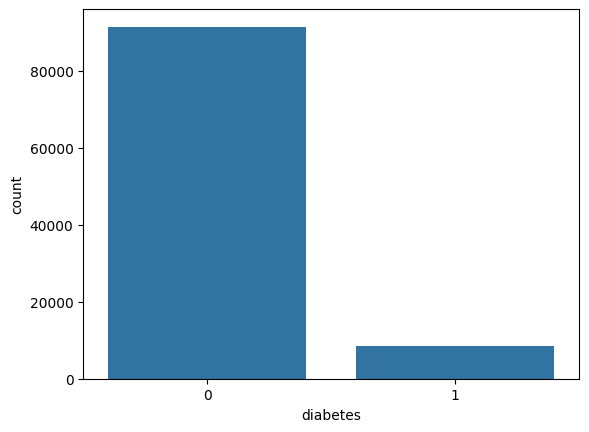

In [19]:
sns.countplot(x='diabetes',data=df)

<Axes: xlabel='gender', ylabel='count'>

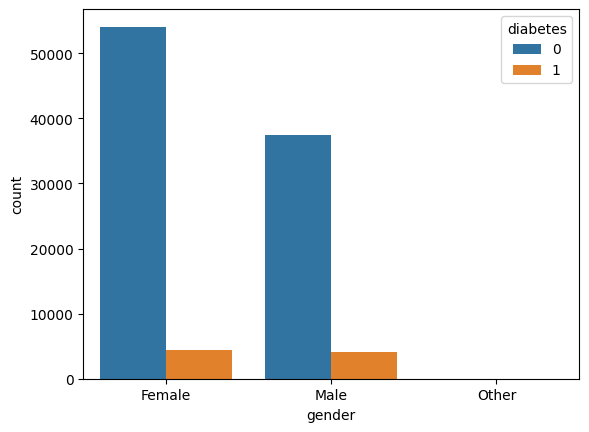

In [40]:
sns.countplot(data=df, x='gender', hue='diabetes')

<Axes: xlabel='age', ylabel='Count'>

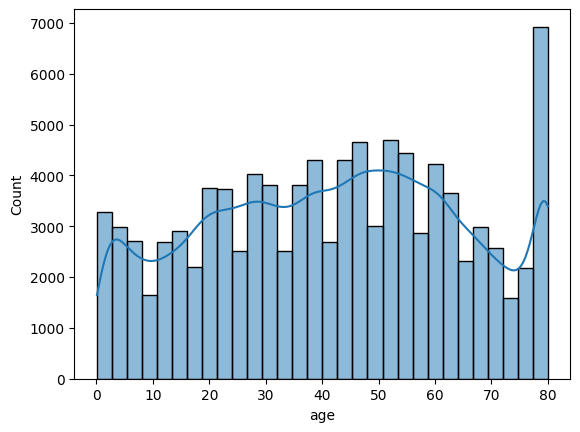

In [29]:
sns.histplot(df['age'],bins=30,kde=True)

<Axes: xlabel='bmi', ylabel='Count'>

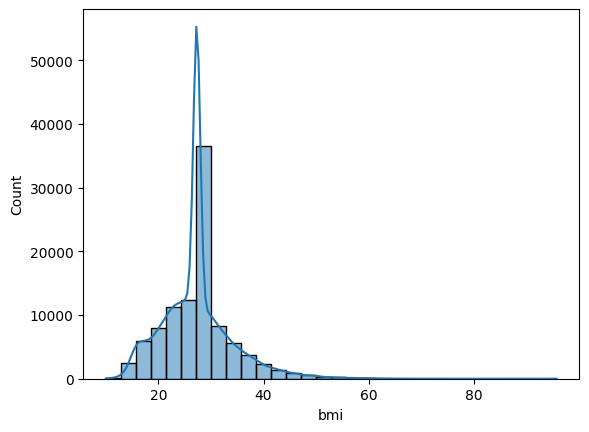

In [30]:
sns.histplot(df['bmi'],bins=30,kde=True)

<Axes: xlabel='hypertension', ylabel='count'>

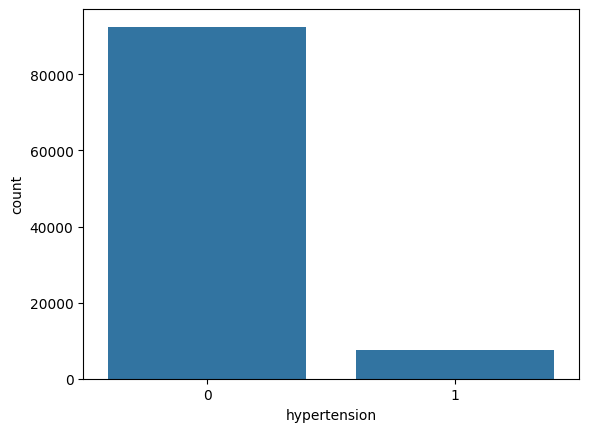

In [31]:
sns.countplot(x='hypertension',data=df)

<Axes: xlabel='heart_disease', ylabel='count'>

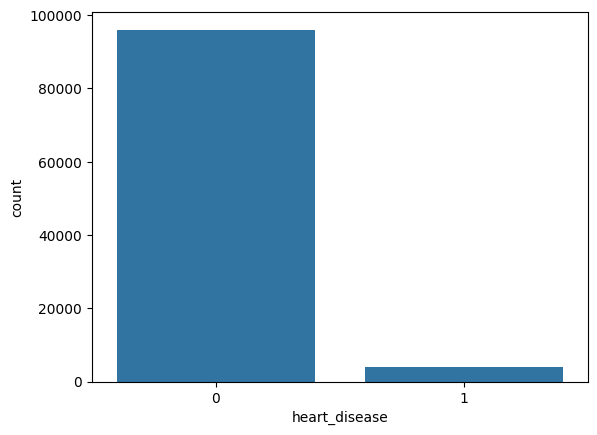

In [32]:
sns.countplot(x='heart_disease',data=df)

<Axes: xlabel='smoking_history', ylabel='count'>

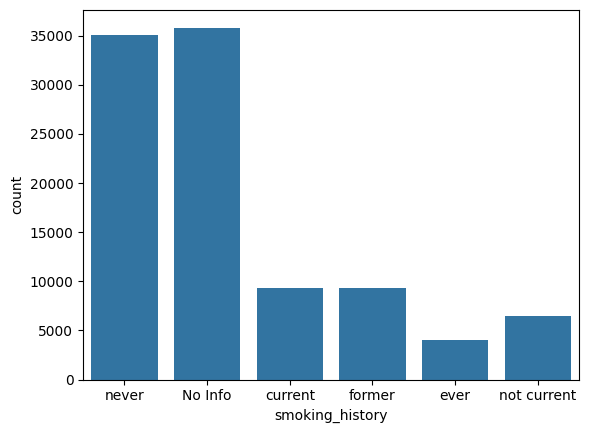

In [33]:
sns.countplot(x='smoking_history',data=df)

<Axes: >

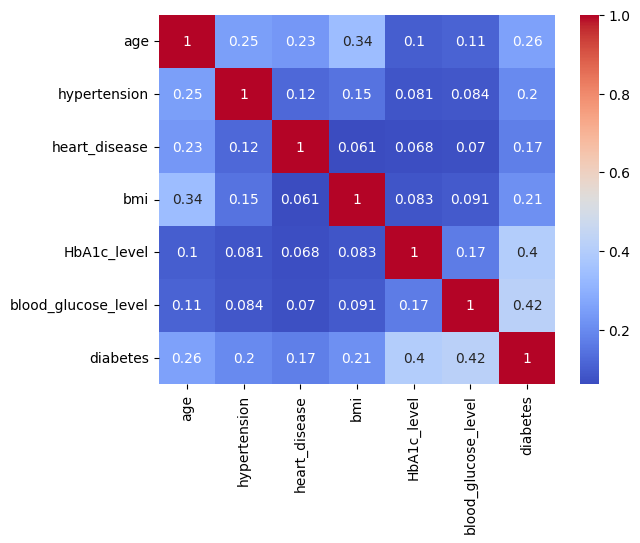

In [26]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [27]:
df['smoking_history'].value_counts()

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [28]:
df['gender'].value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

<Axes: xlabel='diabetes', ylabel='bmi'>

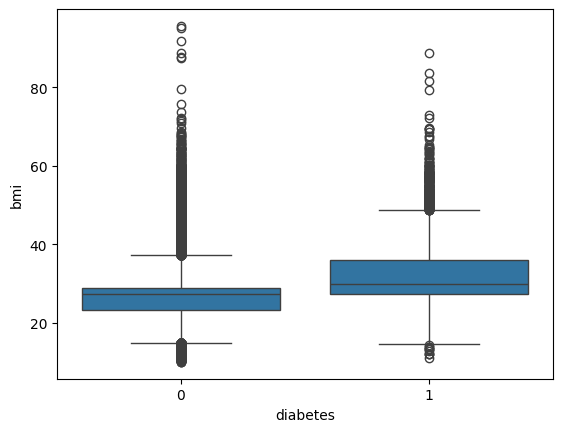

In [35]:
sns.boxplot(x='diabetes', y='bmi', data=df)

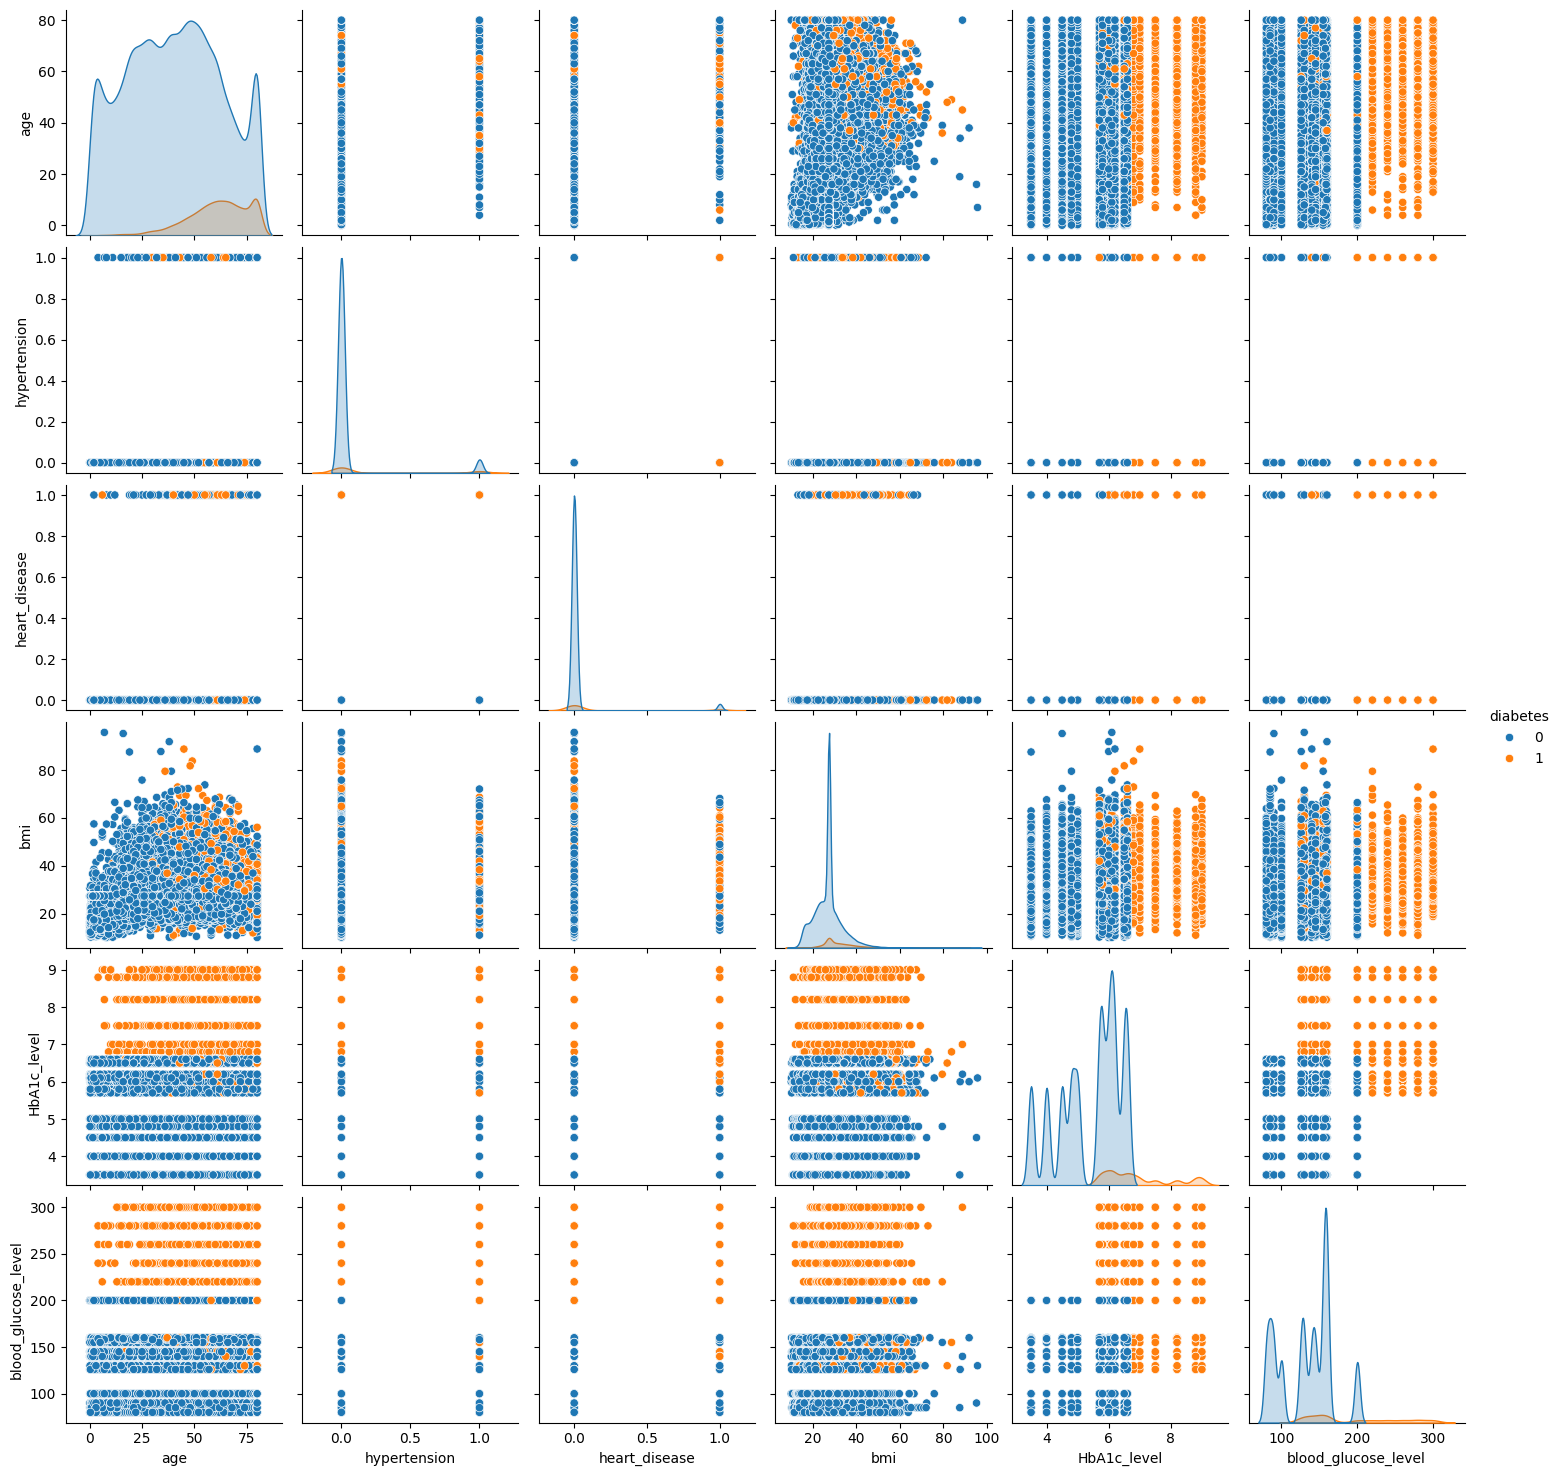

In [41]:
sns.pairplot(df, hue='diabetes')

## **Chapter 3 – Data Cleaning (Data Quality)**

### 1. Check for Duplicates

In [43]:
df[df.duplicated()].shape

(3854, 9)

As we can see here we have 3,854 duplicate rows that must be removed

In [44]:
df.drop_duplicates(inplace=True)

After removing we recheck

In [45]:
df[df.duplicated()].shape

(0, 9)

### 2. Check for Missing Values

In [46]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


As we can see here there are no missing values, but in the EDA chapter we have noticed several missing values that have labels, we will deal with them later on

### 3. Remove the "Other" from gender feature

In [51]:
df.drop(df[df['gender'] == 'Other'].index, inplace=True)

In [52]:
df['gender'].value_counts()

gender
Female    56161
Male      39967
Name: count, dtype: int64

### 4. Remove the "No Info" from smoking_history feature

In [55]:
df.drop(df[df['smoking_history'] == 'No Info'].index, inplace=True)

In [56]:
df['smoking_history'].value_counts()

smoking_history
never          34395
former          9299
current         9197
not current     6359
ever            3997
Name: count, dtype: int64

### 5. Dealing with Outliers

Our models are tree-based ensemble models

All our models (RandomForest, GradientBoosting, XGBoost, Voting Ensemble) are robust to outliers because they:

- Split on thresholds

- Do NOT rely on mean-based distances

- Are not affected by extreme values the way KNN, SVM, or Linear Regression are

So outliers do not hurt performance for tree models.

## **Chapter 4 – Feature Engineering (Encoding)**

The `smoking_history` column is a categorical feature with five distinct categories:  
- never  
- former  
- current  
- not current  
- ever  

Machine learning models cannot directly interpret these text-based categories, so the feature must be converted into a numerical format. To achieve this, we apply **One-Hot Encoding**, which creates a separate binary column for each smoking category.  

This transformation ensures that:
- No ordinal relationship is implied between categories  
- The model receives clean, numerical inputs  
- Each smoking pattern is represented independently  

After encoding, the original `smoking_history` column is replaced with five new dummy variables, allowing the ensemble models to learn from the relationship between smoking behavior and diabetes risk without introducing bias or incorrect ordering.

---


In [57]:
df = pd.get_dummies(df, columns=['smoking_history'], drop_first=True)

In [58]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='object')

The `gender` column contains two valid categories after removing the rare "Other" entries:
- Male  
- Female  

Since machine learning models cannot work directly with text categories, the feature is transformed using **One-Hot Encoding**. This conversion creates a binary variable representing each gender category.

In [59]:
df = pd.get_dummies(df, columns=['gender'])

In [60]:
df.columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current', 'gender_Female', 'gender_Male'],
      dtype='object')

## **Chapter 5 – Splitting and Preparing the Dataset**

### 1. Dataset Split


After encoding the categorical features, the dataset is divided into **training** and **testing** sets. The features (X) include all input variables, while the target (y) is the diabetes outcome.

An **80/20 split** is used:

- **80%** → training the models  
- **20%** → evaluating final performance  

A **stratified split** ensures that the ratio of diabetic vs. non-diabetic cases remains balanced in both sets. A fixed `random_state` is used for reproducibility.


In [61]:
from sklearn.model_selection import train_test_split

In [62]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [64]:
X_train.shape, X_test.shape

((50597, 12), (12650, 12))

### 2. Scaling and Normalization

Preprocessing is a crucial step before training the model. In this case, numerical features are standardized (mean removed and scaled to unit variance), and categorical features are one-hot encoded. **Standardization** is not required for all models but is generally a good practice. **One-hot encoding** is necessary for categorical variables to be correctly understood by the machine learning model.

The **StandardScaler** in sklearn is based on the assumption that the data may not strictly follow a Gaussian (normal) distribution, but we still transform it so that the resulting values have a mean of 0 and a standard deviation of 1.

In other words, given a feature vector \( x \), StandardScaler transforms each value as:

\[
Y_i = \frac{x_i - \mu(\vec{x})}{\sigma(\vec{x})}
\]


### where:

- \( x_i \) is the i-th element of the original feature vector \( \vec{x} \)  
- \( \mu(\vec{x}) \) is the mean of the feature  
- \( \sigma(\vec{x}) \) is the standard deviation of the feature  

After transformation, the new values \( Y \) (each \( Y_i \)) will satisfy:

\[
mean(Y) = 0 \quad\text{and}\quad std(Y) = 1
\]

This transformation is also known as **Z-score normalization**.

In [66]:
from sklearn.preprocessing import StandardScaler

In [65]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']


In [ ]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### 3. SMOTE (inbalance dataset)

Since the diabetes dataset is imbalanced, the minority class (diabetic cases) is under-represented. To address this, SMOTE (Synthetic Minority Oversampling Technique) is applied **only on the training data**. SMOTE generates new synthetic samples for the minority class by interpolating between existing observations. This helps the model learn more balanced patterns and prevents bias toward the majority class, while keeping the test set untouched for a fair evaluation.

In [68]:
from imblearn.over_sampling import SMOTE

In [69]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

## **Chapter 6 – Model Training**

After preprocessing, scaling, and applying SMOTE on the training data, the next step is to train different machine learning models.  
We start with a **baseline model** (Logistic Regression), and then train three ensemble learning models from the Bagging, Boosting, and Voting families.

---

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

### Model 1 — Logistic Regression (Baseline Model)

Logistic Regression is used as the baseline classifier.  
It provides a simple, interpretable model against which we compare all ensemble models.

This model assumes a linear relationship between the input features and the log-odds of the target.  
Although simple, it establishes a performance reference and helps determine how much improvement the ensemble methods provide.

In [71]:
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')

### Model 2 — Random Forest (Bagging Ensemble)

Random Forest is a Bagging-based ensemble model that builds multiple decision trees on bootstrapped samples of the data.  
Each tree learns different patterns, and the final prediction is obtained by majority voting.

This model reduces variance and is highly robust to noise, outliers, and unscaled features.  
It captures complex nonlinear relationships and typically performs significantly better than the baseline model.

In [72]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

### Model 3 — XGBoost (Boosting Ensemble)

XGBoost is a powerful Gradient Boosting algorithm that builds trees sequentially, where each new tree corrects the errors of the previous ones.  
It uses gradient optimization, regularization, and smart tree-pruning to achieve high performance.

XGBoost is often the top performer on structured/tabular datasets and is expected to outperform Logistic Regression and Random Forest due to its strong ability to model nonlinear and interaction effects.


In [73]:
xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

### Model 4 — Voting Classifier (Soft Voting Ensemble)

The Voting Classifier is a meta-ensemble model that combines predictions from multiple classifiers.  
In **soft voting**, each model contributes its predicted probabilities, and the final prediction is made based on the weighted average of these probabilities.


In [74]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', rf_clf),
        ('xgb', xgb_clf)
    ],
    voting='soft'
)

Now we will train the four models 

In [ ]:
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_clf,
    "XGBoost": xgb_clf,
    "Voting Classifier": voting_clf
}

In [ ]:
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_res, y_train_res)

print("\n✅ All models trained successfully.")


Training Logistic Regression...

Training Random Forest...

Training XGBoost...

Training Voting Classifier...

✅ All models trained successfully.


## **Chapter 7 – Model Evaluation & Performance Analysis**

After training the classification models, each model is evaluated individually on the unseen test set.  
The purpose of this phase is to assess how well each classifier generalizes to new data and to compare their strengths and weaknesses before selecting the best-performing model.

The following evaluation metrics are used:

- **Accuracy** – proportion of correct predictions  
- **Precision** – how many predicted positive cases are actually positive  
- **Recall (Sensitivity)** – how many actual positive cases are detected correctly  
- **F1-score** – harmonic mean of precision and recall  
- **ROC–AUC** – ability of the model to separate the two classes across thresholds  
- **Classification Report** – full breakdown of per-class performance  

Since the dataset is imbalanced, metrics like **Precision**, **Recall**, **F1**, and **AUC** are more important than accuracy.

---


In [ ]:
from sklearn.metrics import  roc_auc_score, classification_report

### 1. Logistic Regression 

In [85]:
y_pred_lr = log_reg.predict(X_test)
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.98      0.88      0.93     11243
           1       0.48      0.87      0.62      1407

    accuracy                           0.88     12650
   macro avg       0.73      0.88      0.77     12650
weighted avg       0.93      0.88      0.89     12650



In [ ]:
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]
lr_auc  = roc_auc_score(y_test, y_proba_lr)
print(f"ROC-AUC:   {lr_auc:.4f}")

ROC-AUC:   0.9622


### 2. Random Forest

In [89]:
y_pred_rf = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     11243
           1       0.78      0.75      0.76      1407

    accuracy                           0.95     12650
   macro avg       0.88      0.86      0.87     12650
weighted avg       0.95      0.95      0.95     12650



In [91]:
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]
rf_auc  = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC:   {rf_auc:.4f}")

ROC-AUC:   0.9622


### 3. XGBoost

In [92]:
y_pred_xgb = xgb_clf.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11243
           1       0.90      0.73      0.80      1407

    accuracy                           0.96     12650
   macro avg       0.93      0.86      0.89     12650
weighted avg       0.96      0.96      0.96     12650



In [93]:
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]
xgb_auc  = roc_auc_score(y_test, y_proba_xgb)
print(f"ROC-AUC:   {xgb_auc:.4f}")

ROC-AUC:   0.9719


### 4. Voting Classifier

In [94]:
y_pred_voting = voting_clf.predict(X_test)
print(classification_report(y_test, y_pred_voting))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     11243
           1       0.74      0.78      0.76      1407

    accuracy                           0.94     12650
   macro avg       0.85      0.87      0.86     12650
weighted avg       0.95      0.94      0.95     12650



In [95]:
y_proba_voting = voting_clf.predict_proba(X_test)[:, 1]
voting_auc  = roc_auc_score(y_test, y_proba_voting)
print(f"ROC-AUC:   {voting_auc:.4f}")

ROC-AUC:   0.9677


## **Chapter 8 – Conclusion**

## 1. Model Selection

After evaluating each classifier individually, the next step is to compare their performance across all key evaluation metrics.  
This comparison helps identify the model that provides the best balance between accuracy, precision, recall, F1-score, and ROC–AUC.

Since the dataset is imbalanced, **F1-score** and **ROC–AUC** are considered the most meaningful indicators of performance.


In [110]:
import pandas as pd
from sklearn.metrics import f1_score

model_results = [
    {
        "Model": "Logistic Regression",
        "F1-score": f1_score(y_test, y_pred_lr),
        "ROC-AUC": lr_auc
    },
    {
        "Model": "Random Forest",
        "F1-score": f1_score(y_test, y_pred_rf),
        "ROC-AUC": rf_auc
    },
    {
        "Model": "XGBoost",
        "F1-score": f1_score(y_test, y_pred_xgb),
        "ROC-AUC": xgb_auc
    },
    {
        "Model": "Voting Classifier",
        "F1-score": f1_score(y_test, y_pred_voting),
        "ROC-AUC": voting_auc
    }
]

comparison_df = pd.DataFrame(model_results)

comparison_df = comparison_df.sort_values( by=["F1-score", "ROC-AUC"],ascending=False).reset_index(drop=True)
best_model


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## **Chapter 9 – Testing the Best Model**

To assess the practical usefulness of the trained model, a real example from the dataset was selected and used for testing.  
A **random individual who actually has diabetes** was extracted from the dataset, and the target label was removed to simulate an unseen case.

The numerical features of this person were standardized using the **same scaler** fitted during preprocessing to ensure consistency with the model’s training conditions.  
The sample was then passed to the final selected model for prediction.

This testing step demonstrates how the model behaves on a realistic input and verifies whether it can correctly identify a diabetic case based on the medical feature values provided.

The output includes:

- The **true label** of the selected patient  
- The **model’s predicted class** (Diabetic / Not Diabetic)  
- The **prediction probability**, reflecting the model’s confidence  

This evaluation helps validate whether the model performs reliably when applied to individual real-world cases.

---

### 1. Predicting on a person that has diabetes

In [ ]:
diabetic_df = df[df['diabetes'] == 1]

sample = diabetic_df.sample(1, random_state=42)
sample


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,gender_Female,gender_Male
49111,61.0,0,0,27.32,7.5,300,1,False,False,True,False,False,True


In [ ]:
true_label = sample['diabetes'].values[0]
print("True Label:", true_label)

True Label: 1


In [ ]:
person = sample.drop(columns=['diabetes'])

In [ ]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

person[num_cols] = scaler.transform(person[num_cols])

In [115]:
pred = best_model.predict(person)[0]
proba = best_model.predict_proba(person)[0][1]

print("Model Prediction:", "Diabetic" if pred == 1 else "Not Diabetic")
print("Probability:", proba)


Model Prediction: Diabetic
Probability: 0.99998677


### 2. Predicting on a person that does not have diabetes

In [116]:
diabetic_df = df[df['diabetes'] == 0]

sample = diabetic_df.sample(1, random_state=42)
sample

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,gender_Female,gender_Male
17298,42.0,0,0,27.32,5.7,158,0,False,False,True,False,True,False


In [117]:
true_label = sample['diabetes'].values[0]
print("True Label:", true_label)

True Label: 0


In [118]:
person = sample.drop(columns=['diabetes'])

In [119]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

person[num_cols] = scaler.transform(person[num_cols])

In [120]:
pred = best_model.predict(person)[0]
proba = best_model.predict_proba(person)[0][1]

print("Model Prediction:", "Diabetic" if pred == 1 else "Not Diabetic")
print("Probability:", proba)


Model Prediction: Not Diabetic
Probability: 0.032587294
